# Real Estate Image Captioning — GRU Decoder v2

Mirror of the LSTM v2 decoder (`DecoderLSTM/lstm_Decoder-v2.ipynb`) with the
recurrent cell swapped from LSTM to GRU. Every other architectural choice
(feature gating, scheduled sampling, weight tying, OneCycleLR, beam search,
full eval suite) is kept identical so the GRU-vs-LSTM comparison is fair.

**Encoder pairing:** consumes `encoder_for_decoder.pth` exported by the
EfficientNet-B0 encoder in `EncoderEfficientNet/`. The encoder class is
rebuilt from scratch and its weights are frozen — only the GRU decoder
trains.

**Key GRU-specific differences vs. LSTM v2:**

| | LSTM v2 | GRU v2 (this notebook) |
|---|---|---|
| Hidden state | `(h, c)` | `h` only |
| Init layers | `init_h` + `init_c` | `init_h` only |
| Recurrent init trick | forget-bias = 1 | update-gate bias = −1 (PyTorch GRU bias layout) |
| Param count | higher (4 gates × W) | lower (~25% fewer params per layer) |
| Memory | longer-range via cell state | shorter-range, more compact |

In [29]:
!find /kaggle/input -name "encoder_for_decoder.pth"

/kaggle/input/datasets/joox1113/interior-room-images-captions-houzz/EfficientNet weights/EfficientNet weights/encoder_for_decoder.pth


In [30]:
# %% ===============================
# 1. INSTALL EXTRA LIBRARIES
# ===============================
!pip install nltk rouge-score --quiet
import nltk
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)


True

In [31]:
# %% ===============================
# 2. IMPORTS
# ===============================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from torchvision import models, transforms
from torchvision.models import EfficientNet_B0_Weights

from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import json
import os
from pathlib import Path

from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from rouge_score import rouge_scorer


In [32]:
# %% ===============================
# 3. DEVICE SETUP
# ===============================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')

# Seeds for reproducibility (best-effort — cuDNN has nondeterminism)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


Device: cuda
  GPU 0: Tesla T4
  GPU 1: Tesla T4


In [33]:
# %% ===============================
# 4. HYPERPARAMETERS
# ===============================
# Originally inherited LR=3e-3 / GRAD_CLIP=5.0 from LSTM v2 — that recipe
# diverged around epoch 11 on GRU (gradient explosion, val acc collapsed
# from 0.47 -> 0.10). GRUs are more sensitive to high LR than LSTMs because
# there's no cell state to buffer gradients. Halved peak LR + tighter clip
# stabilizes training so the v2 tricks (scheduled sampling, OneCycleLR cosine
# phase, weight tying) actually take effect over the full 50 epochs.
EMBED_DIM     = 256
HIDDEN_DIM    = 512
NUM_LAYERS    = 2
DROPOUT       = 0.4
BATCH_SIZE    = 32
NUM_EPOCHS    = 50
LR            = 1e-3     # was 3e-3 — peak LR cut to prevent gradient explosion
GRAD_CLIP     = 1.0      # was 5.0 — tighter clip catches bad batches earlier
MAX_SEQ_LEN   = 40
PATIENCE      = 10
LABEL_SMOOTH  = 0.1
WEIGHT_DECAY  = 1e-4

# Scheduled sampling: start with full teacher forcing, linearly reduce
SS_START      = 1.0
SS_END        = 0.7


In [34]:
# %% ===============================
# 5. LOAD ENCODER CHECKPOINT
# ===============================
# Path to your EfficientNet encoder export (from EncoderEfficientNet/).
# Upload `encoder_for_decoder.pth` as a Kaggle dataset and point ENCODER_PATH at it.
# Example: '/kaggle/input/datasets/<your-username>/efficientnet-encoder/encoder_for_decoder.pth'
ENCODER_PATH = '/kaggle/input/datasets/joox1113/interior-room-images-captions-houzz/EfficientNet weights/EfficientNet weights/encoder_for_decoder.pth'
ckpt = torch.load(ENCODER_PATH, map_location=device)

# Pull vocab + image normalization stats from the checkpoint
word2idx    = ckpt['word2idx']
idx2word    = ckpt['idx2word']
vocab_size  = ckpt['vocab_size']
pad_idx     = ckpt['pad_idx']
start_idx   = ckpt['start_idx']
end_idx     = ckpt['end_idx']
img_mean    = ckpt['img_mean']
img_std     = ckpt['img_std']

# Sanity-check: this decoder is built for EfficientNet-B0
backbone_tag = ckpt.get('backbone', '<unknown>')
print(f'Backbone tag in checkpoint: {backbone_tag}')
assert backbone_tag == 'efficientnet_b0', (
    f"Expected efficientnet_b0 encoder, got '{backbone_tag}'. "
    f"This notebook rebuilds EncoderEfficientNetB0 — point ENCODER_PATH at the "
    f"EfficientNet export from EncoderEfficientNet/."
)

print(f'Vocab size : {vocab_size}')
print(f'Embed dim  : {ckpt["embed_dim"]}')
print(f'PAD={pad_idx}, START={start_idx}, END={end_idx}')


Backbone tag in checkpoint: efficientnet_b0
Vocab size : 4207
Embed dim  : 256
PAD=0, START=1, END=2


In [35]:
# %% ===============================
# 6. DATA PATHS + EXPLORE
# ===============================
# Same dataset as the encoder run
DATASET_ROOT = '/kaggle/input/datasets/joox1113/interior-room-images-captions-houzz'
PREP         = f'{DATASET_ROOT}/for data kaggle/for data kaggle/stage3_preprocessing/preprocessing_outputs'
IMAGES_BASE  = f'{DATASET_ROOT}/images/images'

TRAIN_CSV = f'{PREP}/split_train.csv'
VAL_CSV   = f'{PREP}/split_val.csv'
TEST_CSV  = f'{PREP}/split_test.csv'

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

# Parse the stringified token lists
for df in (train_df, val_df, test_df):
    df['tokens'] = df['tokens'].apply(eval)

print(f'Train: {len(train_df):,}')
print(f'Val  : {len(val_df):,}')
print(f'Test : {len(test_df):,}')

# Quick sanity check: a few image paths should exist
sample = train_df.iloc[0]
img_name = '/'.join(sample['local_path'].split('/')[1:])
sample_path = Path(IMAGES_BASE) / img_name
print(f'Sample image exists: {sample_path.exists()}  ({sample_path})')


Train: 10,984
Val  : 1,373
Test : 1,374
Sample image exists: True  (/kaggle/input/datasets/joox1113/interior-room-images-captions-houzz/images/images/home-office/home-office_00740.jpg)


In [36]:
# %% ===============================
# 7. DATASET + DATALOADERS
# ===============================
class CaptionDataset(Dataset):
    def __init__(self, df, images_base, transform=None, max_seq_len=MAX_SEQ_LEN):
        self.df          = df.reset_index(drop=True)
        self.images_base = Path(images_base)
        self.transform   = transform
        self.max_seq_len = max_seq_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_name = '/'.join(row['local_path'].split('/')[1:])
        image    = Image.open(self.images_base / img_name).convert('RGB')
        if self.transform:
            image = self.transform(image)
        # Tokens column is already a list of ints (start/end/pad-padded to MAX_SEQ_LEN)
        caption = torch.tensor(row['tokens'][:self.max_seq_len], dtype=torch.long)
        return image, caption


# Train-time augmentation (matches encoder training)
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=img_mean, std=img_std),
])

# Validation / test: clean
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=img_mean, std=img_std),
])


def collate_fn(batch):
    images, captions = zip(*batch)
    images   = torch.stack(images, 0)
    captions = pad_sequence(captions, batch_first=True, padding_value=pad_idx)
    return images, captions


train_dataset   = CaptionDataset(train_df, IMAGES_BASE, train_transform)
val_dataset     = CaptionDataset(val_df,   IMAGES_BASE, val_transform)
test_dataset    = CaptionDataset(test_df,  IMAGES_BASE, val_transform)
# Visualization variant: no augmentation, used in qualitative + eval cells
test_dataset_vis = CaptionDataset(test_df, IMAGES_BASE, val_transform)

NUM_WORKERS = min(4, os.cpu_count() or 4)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches  : {len(val_loader)}')
print(f'Test batches : {len(test_loader)}')


Train batches: 344
Val batches  : 43
Test batches : 43


In [37]:
# %% ===============================
# 8. ENCODER (EfficientNet-B0 — rebuilt and loaded from checkpoint)
# ===============================
class EncoderEfficientNetB0(nn.Module):
    """Must match the architecture exported by EncoderEfficientNet/."""

    def __init__(self, embed_dim=256, fine_tune=False, dropout=0.0):
        super().__init__()
        backbone = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

        for p in backbone.parameters():
            p.requires_grad = False
        if fine_tune:
            for p in backbone.features[-2:].parameters():
                p.requires_grad = True

        in_features        = backbone.classifier[1].in_features  # 1280
        backbone.classifier = nn.Identity()
        self.backbone      = backbone

        self.projection = nn.Sequential(
            nn.Linear(in_features, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(1024, embed_dim),
            nn.LayerNorm(embed_dim),
        )

    def forward(self, images):
        features = self.backbone(images)
        return self.projection(features)


# Build encoder, load weights, freeze
encoder = EncoderEfficientNetB0(
    embed_dim=ckpt['embed_dim'],
    fine_tune=False,
    dropout=0.0,
).to(device)
encoder.load_state_dict(ckpt['encoder_state_dict'])
encoder.eval()
for p in encoder.parameters():
    p.requires_grad = False

print(f'Encoder loaded and frozen ({sum(p.numel() for p in encoder.parameters()):,} params)')


Encoder loaded and frozen (5,582,204 params)


In [38]:
# %% ===============================
# 9. IMPROVED GRU DECODER (v2) — feature gating + scheduled sampling + weight tying
# ===============================
class GRUDecoderV2(nn.Module):

    def __init__(self, vocab_size, embed_dim=256, hidden_dim=512,
                 num_layers=2, dropout=0.4, pad_idx=0):
        super().__init__()
        self.vocab_size = vocab_size
        self.embed_dim  = embed_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.pad_idx    = pad_idx

        # Word embedding
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        # Feature gate: at each timestep, modulate which image features matter.
        # Input: [top hidden state | current word embedding] -> sigmoid gate.
        self.feat_gate = nn.Sequential(
            nn.Linear(hidden_dim + embed_dim, embed_dim),
            nn.Sigmoid(),
        )

        # GRU: input = [word_embed | gated_features] = embed_dim * 2
        self.gru = nn.GRU(
            input_size=embed_dim * 2,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # Initialize h0 from image features (GRU has no cell state)
        self.init_h = nn.Linear(embed_dim, hidden_dim * num_layers)

        # Output projection + weight tying (embed <-> output FC share weights)
        self.dropout = nn.Dropout(dropout)
        if embed_dim == hidden_dim:
            self.fc_out = nn.Linear(hidden_dim, vocab_size)
            self.fc_out.weight = self.embed.weight
        else:
            # Need an intermediate projection so the tied output sits in embed-space
            self.out_proj = nn.Linear(hidden_dim, embed_dim, bias=False)
            self.fc_out   = nn.Linear(embed_dim, vocab_size, bias=True)
            self.fc_out.weight = self.embed.weight

        self._init_weights()

    def _init_weights(self):
        # Embedding: small normal, zero out pad row
        nn.init.normal_(self.embed.weight, mean=0.0, std=0.01)
        with torch.no_grad():
            self.embed.weight[self.pad_idx].fill_(0)

        # GRU: orthogonal for recurrent weights, xavier for input weights.
        # Update-gate bias trick: set to -1 so the model defaults to keeping
        # h_prev (update_gate=sigmoid(z) ~= 0.27 -> mostly carry previous state).
        # PyTorch GRU bias layout (per layer, per direction):
        #   weight_ih_l*: [reset | update | new] each of size hidden
        #   weight_hh_l*: [reset | update | new] each of size hidden
        for name, param in self.gru.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)
                n = param.size(0)
                # Update-gate bias = -1 (encourages long-range memory at init)
                param.data[n // 3 : 2 * n // 3].fill_(-1.0)

        # Linear layers
        for module in [self.init_h, self.feat_gate[0]]:
            if hasattr(module, 'weight'):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def _init_hidden(self, features):
        """Initialize GRU hidden state from image features. Returns h only."""
        B = features.size(0)
        h0 = self.init_h(features)                                          # [B, hidden*layers]
        h0 = h0.view(B, self.num_layers, self.hidden_dim)
        h0 = h0.permute(1, 0, 2).contiguous()                               # [layers, B, hidden]
        return h0

    def forward(self, features, captions, ss_prob=0.0):
        """
        features: [B, embed_dim]
        captions: [B, T]
        Returns logits over T-1 timesteps.
        """
        B, T  = captions.size()
        T_out = T - 1

        h         = self._init_hidden(features)
        embeddings = self.embed(captions)  # [B, T, embed_dim]

        outputs = []
        for t in range(T_out):
            # Teacher forcing vs. scheduled sampling
            if t == 0 or ss_prob == 0.0 or random.random() >= ss_prob:
                word_embed = embeddings[:, t, :]
            else:
                prev_logits = outputs[-1]
                prev_token  = prev_logits.argmax(dim=-1)
                word_embed  = self.embed(prev_token)

            # Feature gate: modulate image features given current context
            h_top = h[-1]                                          # [B, hidden]
            gate_input  = torch.cat([h_top, word_embed], dim=1)     # [B, hidden+embed]
            gate        = self.feat_gate(gate_input)                # [B, embed]
            gated_feats = gate * features                           # [B, embed]

            # GRU input
            gru_input = torch.cat([word_embed, gated_feats], dim=1) # [B, embed*2]
            gru_input = gru_input.unsqueeze(1)                      # [B, 1, embed*2]

            out, h = self.gru(gru_input, h)                         # out: [B, 1, hidden]
            out = out.squeeze(1)                                    # [B, hidden]
            out = self.dropout(out)

            if hasattr(self, 'out_proj'):
                out = self.out_proj(out)                            # [B, embed]
            logits = self.fc_out(out)                               # [B, vocab]

            outputs.append(logits)

        return torch.stack(outputs, dim=1)                          # [B, T-1, vocab]


# Build decoder + smoke test
decoder = GRUDecoderV2(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    pad_idx=pad_idx,
).to(device)

total_params = sum(p.numel() for p in decoder.parameters() if p.requires_grad)
print(f'Decoder trainable params: {total_params:,}')

with torch.no_grad():
    df = torch.zeros(2, 256, device=device)
    dc = torch.zeros(2, 40, dtype=torch.long, device=device)
    do = decoder(df, dc)
    print(f'Decoder output shape: {do.shape}  (expect [2, 39, {vocab_size}])')


Decoder trainable params: 4,824,175
Decoder output shape: torch.Size([2, 39, 4207])  (expect [2, 39, 4207])


In [39]:
# %% ===============================
# 10. LOSS, OPTIMIZER, SCHEDULER (OneCycleLR)
# ===============================
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx, label_smoothing=LABEL_SMOOTH)
optimizer = optim.AdamW(decoder.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

total_steps = len(train_loader) * NUM_EPOCHS
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR,
    total_steps=total_steps,
    pct_start=0.1,
    anneal_strategy='cos',
    div_factor=25,
    final_div_factor=1e4,
)

print('Loss / Optimizer / OneCycleLR ready')
print(f'  Peak LR     : {LR}')
print(f'  Start LR    : {LR / 25:.6f}')
print(f'  Total steps : {total_steps}')


Loss / Optimizer / OneCycleLR ready
  Peak LR     : 0.001
  Start LR    : 0.000040
  Total steps : 17200


In [40]:
# %% ===============================
# 11. TRAINING LOOP (with scheduled sampling)
# ===============================
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}
best_val_loss    = float('inf')
patience_counter = 0

print(f'\n{"=" * 60}')
print(f'Training started — {NUM_EPOCHS} epochs max, patience={PATIENCE}')
print(f'{"=" * 60}\n')

for epoch in range(NUM_EPOCHS):
    # Scheduled-sampling probability (linearly grow from 0 toward 1-SS_END)
    ss_prob = (1.0 - SS_START) + (SS_START - SS_END) * (epoch / max(NUM_EPOCHS - 1, 1))
    ss_prob = max(0.0, min(ss_prob, 1.0 - SS_END))

    # ── TRAIN ──────────────────────────────────────────────────────
    decoder.train()
    train_loss = 0.0
    train_correct = 0
    train_tokens  = 0

    for images, captions in train_loader:
        images   = images.to(device, non_blocking=True)
        captions = captions.to(device, non_blocking=True)

        with torch.no_grad():
            features = encoder(images)                              # [B, 256]

        logits  = decoder(features, captions, ss_prob=ss_prob)      # [B, T-1, V]
        targets = captions[:, 1:]                                   # [B, T-1]

        loss = criterion(logits.reshape(-1, vocab_size), targets.reshape(-1))

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=GRAD_CLIP)
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()
        preds = logits.argmax(dim=-1)
        mask  = targets != pad_idx
        train_correct += ((preds == targets) & mask).sum().item()
        train_tokens  += mask.sum().item()

    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc  = train_correct / max(train_tokens, 1)

    # ── VAL ────────────────────────────────────────────────────────
    decoder.eval()
    val_loss = 0.0
    val_correct = 0
    val_tokens  = 0
    with torch.no_grad():
        for images, captions in val_loader:
            images   = images.to(device, non_blocking=True)
            captions = captions.to(device, non_blocking=True)

            features = encoder(images)
            logits   = decoder(features, captions, ss_prob=0.0)
            targets  = captions[:, 1:]

            loss = criterion(logits.reshape(-1, vocab_size), targets.reshape(-1))

            val_loss += loss.item()
            preds = logits.argmax(dim=-1)
            mask  = targets != pad_idx
            val_correct += ((preds == targets) & mask).sum().item()
            val_tokens  += mask.sum().item()

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc  = val_correct / max(val_tokens, 1)
    current_lr   = optimizer.param_groups[0]['lr']

    # ── SAVE BEST ──────────────────────────────────────────────────
    flag = ''
    if avg_val_loss < best_val_loss:
        best_val_loss    = avg_val_loss
        patience_counter = 0
        torch.save({
            'epoch'        : epoch + 1,
            'decoder'      : decoder.state_dict(),
            'optimizer'    : optimizer.state_dict(),
            'best_val_loss': best_val_loss,
            'vocab_size'   : vocab_size,
            'embed_dim'    : EMBED_DIM,
            'hidden_dim'   : HIDDEN_DIM,
            'num_layers'   : NUM_LAYERS,
        }, '/kaggle/working/best_gru_decoder_v2.pth')
        flag = '  saved'
    else:
        patience_counter += 1

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_acc'].append(avg_train_acc)
    history['val_acc'].append(avg_val_acc)
    history['lr'].append(current_lr)

    print(f'Epoch [{epoch+1:>2}/{NUM_EPOCHS}]  '
          f'lr={current_lr:.6f}  ss={ss_prob:.2f}  '
          f'train={avg_train_loss:.4f}/{avg_train_acc:.4f}  '
          f'val={avg_val_loss:.4f}/{avg_val_acc:.4f}{flag}')

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping — no improvement for {PATIENCE} epochs')
        break

print(f'\nBest val loss: {best_val_loss:.4f}')

with open('/kaggle/working/training_history_v2.json', 'w') as f:
    json.dump(history, f, indent=2)



Training started — 50 epochs max, patience=10

Epoch [ 1/50]  lr=0.000132  ss=0.00  train=6.4988/0.0498  val=5.6703/0.0573  saved
Epoch [ 2/50]  lr=0.000372  ss=0.01  train=5.4974/0.0816  val=5.2661/0.1063  saved
Epoch [ 3/50]  lr=0.000669  ss=0.01  train=4.6819/0.2521  val=4.0522/0.4074  saved
Epoch [ 4/50]  lr=0.000909  ss=0.02  train=3.9543/0.4316  val=3.7305/0.4623  saved
Epoch [ 5/50]  lr=0.001000  ss=0.02  train=3.7703/0.4584  val=3.6294/0.4746  saved
Epoch [ 6/50]  lr=0.000999  ss=0.03  train=3.6695/0.4694  val=3.5906/0.4794  saved
Epoch [ 7/50]  lr=0.000995  ss=0.04  train=3.6072/0.4761  val=3.5520/0.4860  saved
Epoch [ 8/50]  lr=0.000989  ss=0.04  train=3.5533/0.4817  val=3.5263/0.4908  saved
Epoch [ 9/50]  lr=0.000981  ss=0.05  train=3.5086/0.4863  val=3.5111/0.4918  saved
Epoch [10/50]  lr=0.000970  ss=0.06  train=3.4789/0.4895  val=3.5038/0.4944  saved
Epoch [11/50]  lr=0.000957  ss=0.06  train=3.4410/0.4935  val=3.4953/0.4970  saved
Epoch [12/50]  lr=0.000941  ss=0.07  tr

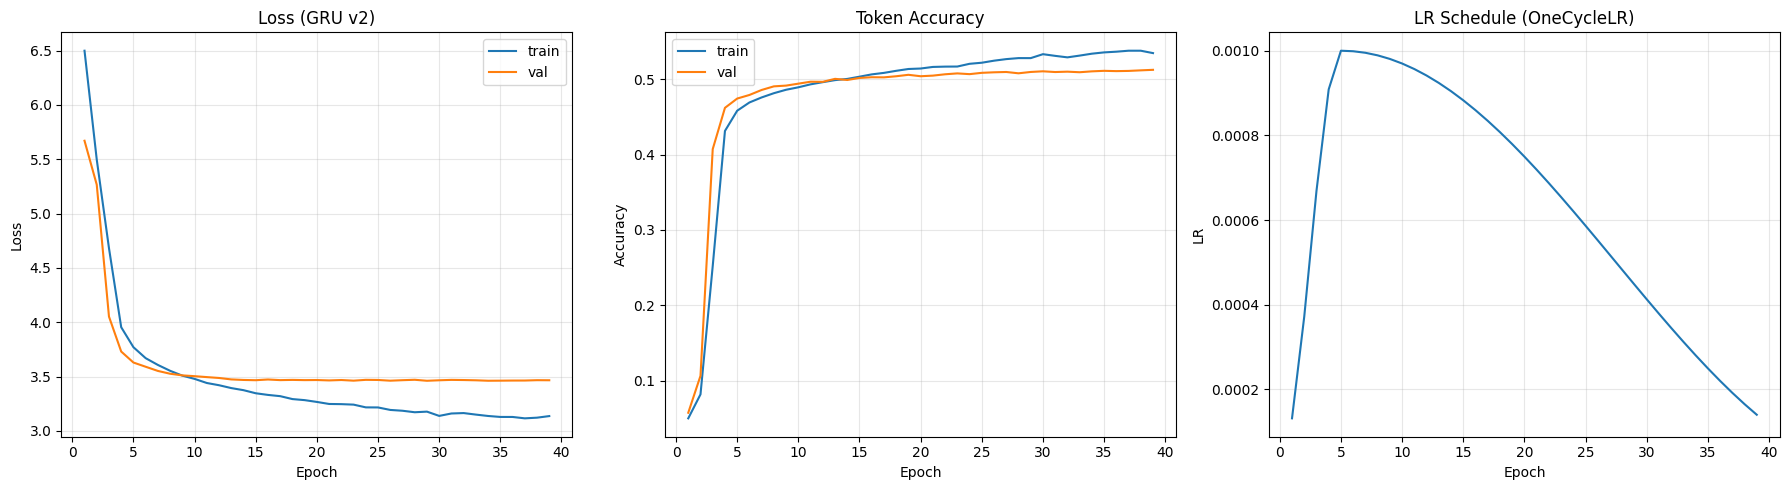

In [41]:
# %% ===============================
# 12. PLOT TRAINING CURVES
# ===============================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_ran = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_ran, history['train_loss'], label='train')
axes[0].plot(epochs_ran, history['val_loss'],   label='val')
axes[0].set_title('Loss (GRU v2)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, history['train_acc'], label='train')
axes[1].plot(epochs_ran, history['val_acc'],   label='val')
axes[1].set_title('Token Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_ran, history['lr'])
axes[2].set_title('LR Schedule (OneCycleLR)')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves_v2.png', dpi=150, bbox_inches='tight')
plt.show()


In [42]:
# %% ===============================
# 13. LOAD BEST MODEL
# ===============================
best_ckpt = torch.load('/kaggle/working/best_gru_decoder_v2.pth', map_location=device)
decoder.load_state_dict(best_ckpt['decoder'])
decoder.eval()
print(f"Loaded best checkpoint (epoch={best_ckpt['epoch']}, val_loss={best_ckpt['best_val_loss']:.4f})")


Loaded best checkpoint (epoch=29, val_loss=3.4615)


In [43]:
# %% ===============================
# 14. CAPTION GENERATION (greedy + beam search) — GRU variants
# ===============================
from nltk.translate.meteor_score import meteor_score as nltk_meteor


def _decode_token_ids(token_ids):
    return ' '.join(idx2word.get(str(t), idx2word.get(t, '<UNK>')) for t in token_ids)


def greedy_decode(encoder, decoder, image, max_len=MAX_SEQ_LEN):
    encoder.eval(); decoder.eval()
    with torch.no_grad():
        features = encoder(image.unsqueeze(0).to(device))           # [1, 256]
        h        = decoder._init_hidden(features)                   # [layers, 1, hidden]
        token    = torch.tensor([[start_idx]], device=device)
        caption  = []

        for _ in range(max_len):
            word_embed = decoder.embed(token).squeeze(1)            # [1, embed]

            h_top      = h[-1]
            gate_in    = torch.cat([h_top, word_embed], dim=1)
            gate       = decoder.feat_gate(gate_in)
            gated_feat = gate * features

            gru_in   = torch.cat([word_embed, gated_feat], dim=1).unsqueeze(1)
            out, h   = decoder.gru(gru_in, h)
            out      = out.squeeze(1)

            if hasattr(decoder, 'out_proj'):
                out = decoder.out_proj(out)
            logits = decoder.fc_out(out)

            next_token = logits.argmax(dim=-1)
            tok_id     = next_token.item()
            if tok_id == end_idx:
                break
            caption.append(tok_id)
            token = next_token.unsqueeze(0)

    return _decode_token_ids(caption)


def beam_search_decode(encoder, decoder, image, beam_size=5, max_len=MAX_SEQ_LEN):
    encoder.eval(); decoder.eval()
    with torch.no_grad():
        features = encoder(image.unsqueeze(0).to(device))           # [1, 256]
        h0       = decoder._init_hidden(features)
        beams    = [(0.0, [start_idx], h0)]                          # (log_prob, seq, h)
        completed = []

        for _ in range(max_len):
            candidates = []
            for log_prob, seq, h_b in beams:
                last_tok   = torch.tensor([[seq[-1]]], device=device)
                word_embed = decoder.embed(last_tok).squeeze(1)

                h_top      = h_b[-1]
                gate_in    = torch.cat([h_top, word_embed], dim=1)
                gate       = decoder.feat_gate(gate_in)
                gated_feat = gate * features

                gru_in        = torch.cat([word_embed, gated_feat], dim=1).unsqueeze(1)
                out, h_new    = decoder.gru(gru_in, h_b)
                out           = out.squeeze(1)

                if hasattr(decoder, 'out_proj'):
                    out = decoder.out_proj(out)
                logits = decoder.fc_out(out)

                log_probs        = torch.log_softmax(logits, dim=-1).squeeze(0)
                top_probs, top_ids = log_probs.topk(beam_size)

                for i in range(beam_size):
                    tok       = top_ids[i].item()
                    new_prob  = log_prob + top_probs[i].item()
                    new_seq   = seq + [tok]
                    if tok == end_idx:
                        score = new_prob / (len(new_seq) ** 0.7)     # length-norm alpha
                        completed.append((score, new_seq))
                    else:
                        candidates.append((new_prob, new_seq, h_new))

            if not candidates:
                break
            candidates.sort(key=lambda x: x[0], reverse=True)
            beams = candidates[:beam_size]
            if len(completed) >= beam_size:
                break

        if completed:
            completed.sort(key=lambda x: x[0], reverse=True)
            best_seq = completed[0][1]
        else:
            best_seq = beams[0][1]

        caption_ids = [t for t in best_seq if t not in (start_idx, end_idx, pad_idx)]
        return _decode_token_ids(caption_ids)


In [44]:
# %% ===============================
# 15. CIDEr SCORE IMPLEMENTATION
# ===============================
from collections import Counter

def compute_cider(references, hypotheses, n=4):
    def get_ngrams(words, n):
        ng = Counter()
        for i in range(1, n + 1):
            for j in range(len(words) - i + 1):
                ng[tuple(words[j:j+i])] += 1
        return ng

    def compute_tf(ngrams, length):
        return {ng: c / max(length, 1) for ng, c in ngrams.items()}

    num_docs = len(references)
    df = Counter()
    for refs in references:
        seen = set()
        for ref in refs:
            for ng in get_ngrams(ref, n):
                if ng not in seen:
                    df[ng] += 1
                    seen.add(ng)

    scores = []
    for hyp, refs in zip(hypotheses, references):
        hyp_tf    = compute_tf(get_ngrams(hyp, n), len(hyp))
        hyp_tfidf = {ng: tf * np.log(max(1.0, num_docs) / max(1.0, df.get(ng, 0)))
                     for ng, tf in hyp_tf.items()}

        ref_scores = []
        for ref in refs:
            ref_tf    = compute_tf(get_ngrams(ref, n), len(ref))
            ref_tfidf = {ng: tf * np.log(max(1.0, num_docs) / max(1.0, df.get(ng, 0)))
                         for ng, tf in ref_tf.items()}

            keys   = set(hyp_tfidf) | set(ref_tfidf)
            dot    = sum(hyp_tfidf.get(k, 0) * ref_tfidf.get(k, 0) for k in keys)
            norm_h = np.sqrt(sum(v * v for v in hyp_tfidf.values())) + 1e-8
            norm_r = np.sqrt(sum(v * v for v in ref_tfidf.values())) + 1e-8
            ref_scores.append(dot / (norm_h * norm_r))

        scores.append(np.mean(ref_scores) if ref_scores else 0.0)

    return 10.0 * float(np.mean(scores))


Qualitative examples — GT vs Greedy vs Beam


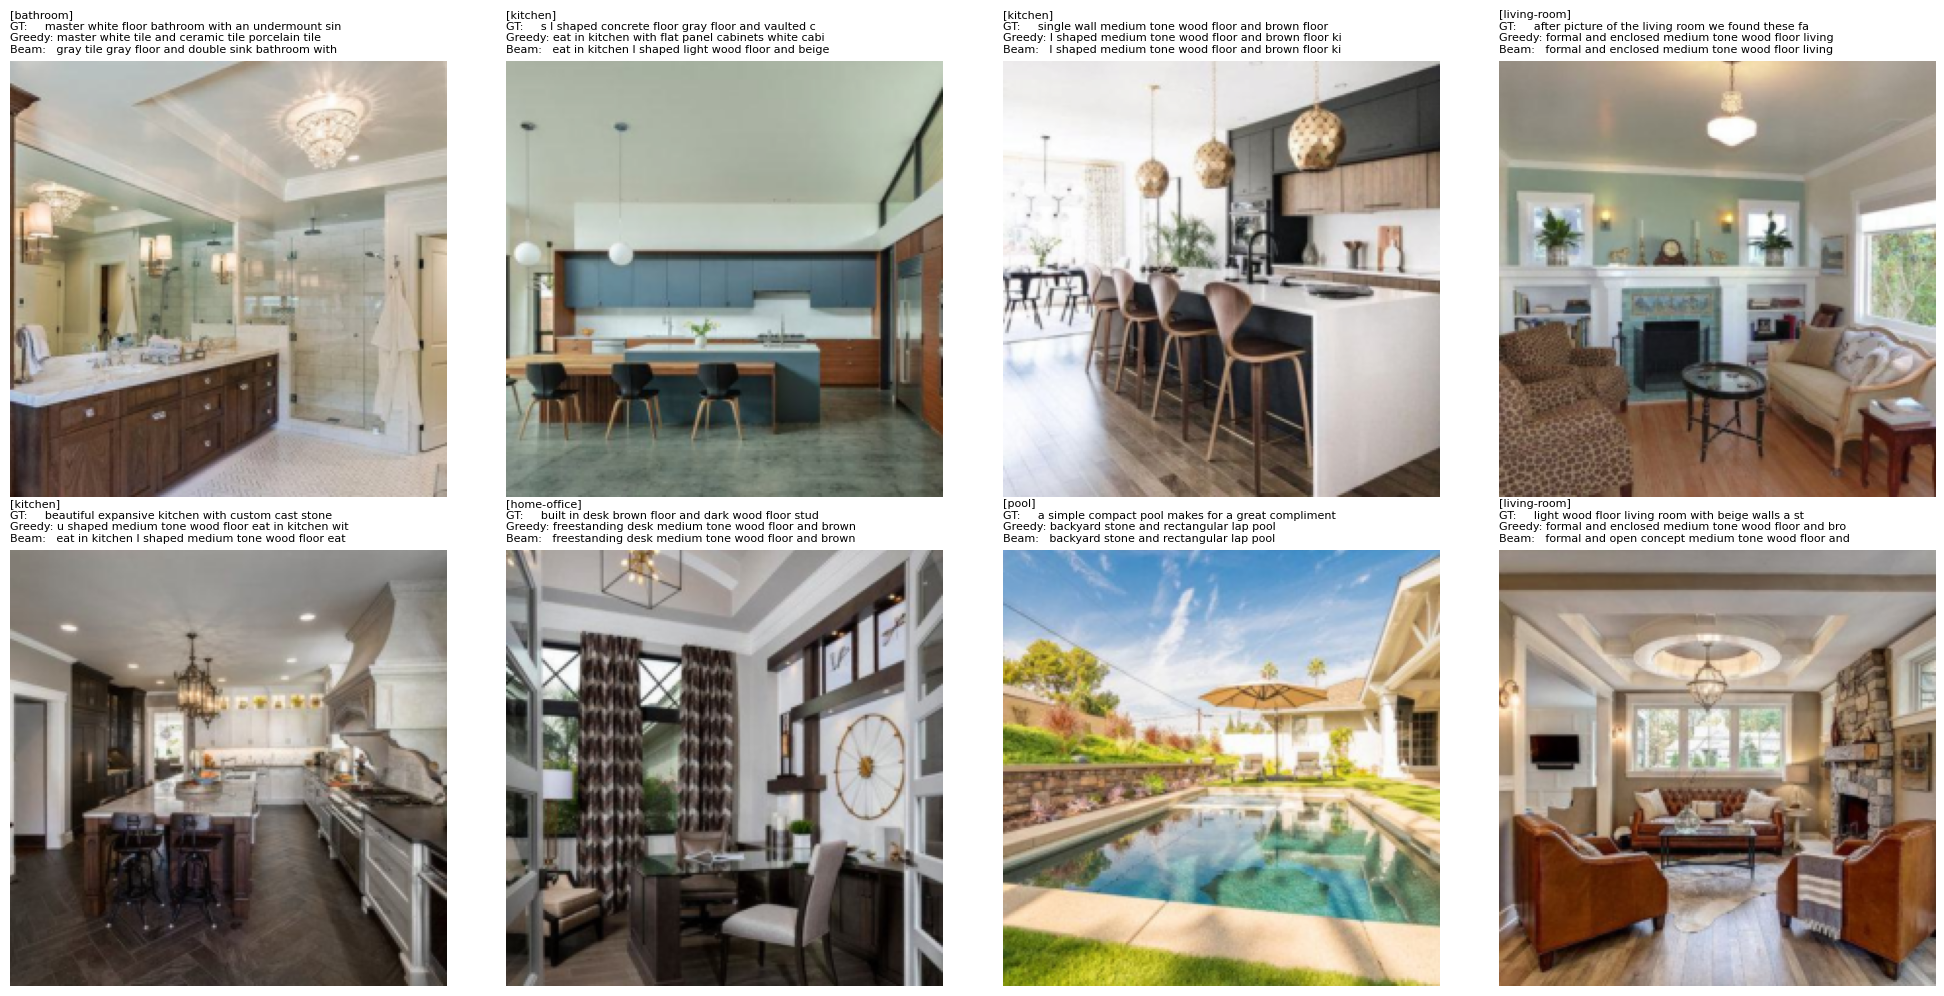

In [45]:
# %% ===============================
# 16. QUALITATIVE EXAMPLES (8 random test images)
# ===============================
print('=' * 60)
print('Qualitative examples — GT vs Greedy vs Beam')
print('=' * 60)

sample_idx = random.sample(range(len(test_dataset_vis)), 8)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, idx in enumerate(sample_idx):
    image, tokens = test_dataset_vis[idx]
    row = test_df.iloc[idx]

    gt_ids   = [t.item() for t in tokens if t.item() not in (start_idx, end_idx, pad_idx)]
    gt_cap   = _decode_token_ids(gt_ids)
    greedy   = greedy_decode(encoder, decoder, image)
    beam     = beam_search_decode(encoder, decoder, image, beam_size=5)

    # Un-normalize the image for display
    img_np = image.permute(1, 2, 0).numpy()
    img_np = img_np * np.array(img_std) + np.array(img_mean)
    img_np = np.clip(img_np, 0, 1)

    ax = axes[i // 4, i % 4]
    ax.imshow(img_np); ax.axis('off')
    ax.set_title(
        f'[{row.room_type}]\n'
        f'GT:     {gt_cap[:50]}\n'
        f'Greedy: {greedy[:50]}\n'
        f'Beam:   {beam[:50]}',
        fontsize=8, loc='left',
    )

plt.tight_layout()
plt.savefig('/kaggle/working/sample_captions_v2.png', dpi=120, bbox_inches='tight')
plt.show()


In [46]:
# %% ===============================
# 17. FULL EVALUATION (BLEU, METEOR, ROUGE-L, CIDEr)
# ===============================
print('\n' + '=' * 60)
print('Full Evaluation on Test Set')
print('=' * 60)

references_all    = []
hypotheses_greedy = []
hypotheses_beam   = []
room_types_all    = []

decoder.eval()
for idx in range(len(test_dataset_vis)):
    image, tokens = test_dataset_vis[idx]
    row = test_df.iloc[idx]

    gt_ids   = [t.item() for t in tokens if t.item() not in (start_idx, end_idx, pad_idx)]
    gt_words = [idx2word.get(str(t), idx2word.get(t, '<UNK>')) for t in gt_ids]
    references_all.append([gt_words])
    room_types_all.append(row['room_type'])

    hypotheses_greedy.append(greedy_decode(encoder, decoder, image).split())
    if idx < 500:  # beam search is slow — sample first 500
        hypotheses_beam.append(beam_search_decode(encoder, decoder, image, beam_size=5).split())

    if (idx + 1) % 200 == 0:
        print(f'  evaluated {idx + 1}/{len(test_dataset_vis)}')

print(f'  evaluated {len(test_dataset_vis)}/{len(test_dataset_vis)} — done')

smooth = SmoothingFunction().method1
bleu1_greedy = corpus_bleu(references_all, hypotheses_greedy, weights=(1.0, 0, 0, 0), smoothing_function=smooth)
bleu4_greedy = corpus_bleu(references_all, hypotheses_greedy, weights=(0.25,) * 4, smoothing_function=smooth)
bleu1_beam   = corpus_bleu(references_all[:500], hypotheses_beam, weights=(1.0, 0, 0, 0), smoothing_function=smooth)
bleu4_beam   = corpus_bleu(references_all[:500], hypotheses_beam, weights=(0.25,) * 4, smoothing_function=smooth)

print('\nComputing METEOR ...')
meteor_scores = [
    nltk_meteor([refs[0]], hyp) for refs, hyp in zip(references_all, hypotheses_greedy)
]
meteor_greedy = float(np.mean(meteor_scores))

print('Computing ROUGE-L ...')
rscorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
rouge_scores = [
    rscorer.score(' '.join(refs[0]), ' '.join(hyp))['rougeL'].fmeasure
    for refs, hyp in zip(references_all, hypotheses_greedy)
]
rouge_l_greedy = float(np.mean(rouge_scores))

print('Computing CIDEr ...')
cider_greedy = compute_cider(references_all, hypotheses_greedy)

print('\n' + '=' * 60)
print('RESULTS (test set)')
print('=' * 60)
print(f'BLEU-1  greedy: {bleu1_greedy:.4f}   beam: {bleu1_beam:.4f}')
print(f'BLEU-4  greedy: {bleu4_greedy:.4f}   beam: {bleu4_beam:.4f}')
print(f'METEOR  : {meteor_greedy:.4f}')
print(f'ROUGE-L : {rouge_l_greedy:.4f}')
print(f'CIDEr   : {cider_greedy:.4f}')



Full Evaluation on Test Set
  evaluated 200/1374
  evaluated 400/1374
  evaluated 600/1374
  evaluated 800/1374
  evaluated 1000/1374
  evaluated 1200/1374
  evaluated 1374/1374 — done

Computing METEOR ...
Computing ROUGE-L ...
Computing CIDEr ...

RESULTS (test set)
BLEU-1  greedy: 0.3895   beam: 0.2448
BLEU-4  greedy: 0.1809   beam: 0.1179
METEOR  : 0.3548
ROUGE-L : 0.3660
CIDEr   : 1.0913


Overall room-type accuracy: 85.59%


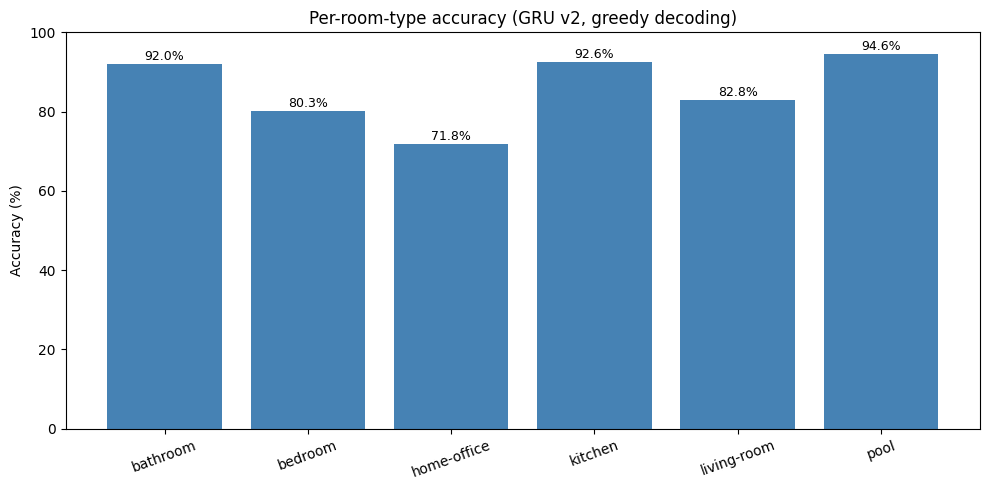

In [47]:
# %% ===============================
# 18. PER-ROOM-TYPE ACCURACY + BAR CHART
# ===============================
room_keywords = {
    'bathroom'   : ['bathroom', 'bath', 'shower', 'tub', 'vanity', 'toilet', 'sink', 'faucet', 'tile'],
    'bedroom'    : ['bedroom', 'bed', 'mattress', 'pillow', 'nightstand', 'headboard', 'sleeping', 'duvet'],
    'home-office': ['office', 'desk', 'study', 'workspace', 'workstation', 'computer', 'bookshelf', 'shelving', 'chair'],
    'kitchen'    : ['kitchen', 'cabinet', 'counter', 'stove', 'oven', 'refrigerator', 'cooking', 'sink', 'island', 'appliance', 'backsplash'],
    'living-room': ['living', 'lounge', 'sofa', 'couch', 'fireplace', 'mantel', 'seating', 'coffee table', 'sectional'],
    'pool'       : ['pool', 'swim', 'patio', 'outdoor', 'deck', 'backyard', 'spa', 'hot tub', 'water', 'lounge'],
}


def room_match(generated, room_type):
    g = generated.lower()
    return any(kw in g for kw in room_keywords.get(room_type, []))


per_room_correct = {rt: [0, 0] for rt in room_keywords}  # [correct, total]
for hyp, rt in zip(hypotheses_greedy, room_types_all):
    per_room_correct[rt][1] += 1
    if room_match(' '.join(hyp), rt):
        per_room_correct[rt][0] += 1

room_acc_total = sum(c for c, _ in per_room_correct.values()) / max(1, sum(t for _, t in per_room_correct.values())) * 100
print(f'Overall room-type accuracy: {room_acc_total:.2f}%')

rooms = list(per_room_correct.keys())
accs  = [100 * c / max(1, t) for c, t in per_room_correct.values()]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(rooms, accs, color='steelblue')
ax.set_ylim(0, 100); ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-room-type accuracy (GRU v2, greedy decoding)')
for b, a in zip(bars, accs):
    ax.text(b.get_x() + b.get_width() / 2, a + 1, f'{a:.1f}%', ha='center', fontsize=9)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('/kaggle/working/room_type_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()


In [48]:
# %% ===============================
# 19. SAVE TEST PREDICTIONS CSV
# ===============================
predictions_rows = []
for idx in range(len(test_dataset_vis)):
    row = test_df.iloc[idx]
    gt   = ' '.join(idx2word.get(str(t), idx2word.get(t, '<UNK>'))
                    for t in row['tokens'] if t not in (start_idx, end_idx, pad_idx))
    pred = ' '.join(hypotheses_greedy[idx])
    predictions_rows.append({
        'local_path'  : row['local_path'],
        'room_type'   : row['room_type'],
        'true_caption': gt,
        'generated'   : pred,
    })

pred_df = pd.DataFrame(predictions_rows)
pred_df.to_csv('/kaggle/working/test_predictions_v2.csv', index=False)
print(f'Saved {len(pred_df):,} predictions to test_predictions_v2.csv')


Saved 1,374 predictions to test_predictions_v2.csv


In [49]:
# %% ===============================
# 20. SAVE METRICS + EXPORT DECODER
# ===============================
metrics = {
    'model'        : 'EfficientNet-B0 (frozen) + GRU v2',
    'best_val_loss': best_val_loss,
    'test_samples' : len(test_dataset_vis),
    'BLEU-1_greedy': bleu1_greedy,
    'BLEU-4_greedy': bleu4_greedy,
    'BLEU-1_beam'  : bleu1_beam,
    'BLEU-4_beam'  : bleu4_beam,
    'METEOR'       : meteor_greedy,
    'ROUGE-L'      : rouge_l_greedy,
    'CIDEr'        : cider_greedy,
    'Room_Acc_%'   : room_acc_total,
    'hyperparams'  : {
        'EMBED_DIM'   : EMBED_DIM,
        'HIDDEN_DIM'  : HIDDEN_DIM,
        'NUM_LAYERS'  : NUM_LAYERS,
        'BATCH_SIZE'  : BATCH_SIZE,
        'LR'          : LR,
        'NUM_EPOCHS'  : NUM_EPOCHS,
        'DROPOUT'     : DROPOUT,
        'GRAD_CLIP'   : GRAD_CLIP,
        'LABEL_SMOOTH': LABEL_SMOOTH,
        'WEIGHT_DECAY': WEIGHT_DECAY,
        'SS_START'    : SS_START,
        'SS_END'      : SS_END,
    },
}

with open('/kaggle/working/eval_metrics_v2.json', 'w') as f:
    json.dump(metrics, f, indent=2)

# Export decoder (vocab + arch info bundled so downstream code is self-contained)
torch.save({
    'decoder_state_dict': decoder.state_dict(),
    'arch'              : 'GRUDecoderV2',
    'vocab_size'        : vocab_size,
    'embed_dim'         : EMBED_DIM,
    'hidden_dim'        : HIDDEN_DIM,
    'num_layers'        : NUM_LAYERS,
    'dropout'           : DROPOUT,
    'pad_idx'           : pad_idx,
    'start_idx'         : start_idx,
    'end_idx'           : end_idx,
    'word2idx'          : word2idx,
    'idx2word'          : idx2word,
    'best_val_loss'     : best_val_loss,
    'metrics'           : metrics,
}, '/kaggle/working/gru_decoder_export.pth')

print('Saved:')
print('  /kaggle/working/eval_metrics_v2.json')
print('  /kaggle/working/gru_decoder_export.pth')
print('  /kaggle/working/test_predictions_v2.csv')
print('  /kaggle/working/training_curves_v2.png')
print('  /kaggle/working/sample_captions_v2.png')
print('  /kaggle/working/room_type_accuracy.png')


Saved:
  /kaggle/working/eval_metrics_v2.json
  /kaggle/working/gru_decoder_export.pth
  /kaggle/working/test_predictions_v2.csv
  /kaggle/working/training_curves_v2.png
  /kaggle/working/sample_captions_v2.png
  /kaggle/working/room_type_accuracy.png
